# BloodMNIST Architecture Comparison: ResNet-50, Swin-Tiny and ViT-B/16

This notebook compares three pretrained models on `BloodMNIST` under the same training strategy.

- `resnet50`
- `swin_tiny_patch4_window7_224`
- `vit_base_patch16_224`

The default experiment is architecture comparison with the same strategy: full fine-tuning on 100% training data.

In [1]:
from pathlib import Path
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import timm
import torch
import torch.nn as nn
from medmnist import BloodMNIST
from sklearn.metrics import f1_score, roc_auc_score
from torch.utils.data import DataLoader, Subset
from torchvision import transforms


f:\课程文档\Term2\DSS5104\Assignment2\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
seed = 42

model_configs = {
    "resnet50": {
        "timm_name": "resnet50",
        "input_size": 224,
        "lr": 1e-4,
    },
    "swin_tiny": {
        "timm_name": "swin_tiny_patch4_window7_224",
        "input_size": 224,
        "lr": 1e-4,
    },
    "vit_b16": {
        "timm_name": "vit_base_patch16_224",
        "input_size": 224,
        "lr": 1e-4,
    },
}

# Fixed setup for architecture comparison under one shared strategy.
strategy_name = "full_fine_tuning"
selected_models = ["resnet50", "swin_tiny", "vit_b16"]
train_fraction = 1.0
freeze_backbone = False
batch_size = 32
num_workers = 4
num_epochs = 12
patience = 3
weight_decay = 1e-4
num_classes = 8

checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

print(f"Using device: {device}")
print(f"Strategy: {strategy_name}")
print(f"Selected models: {selected_models}")
print(f"Train fraction: {train_fraction:.0%}")
print(f"Freeze backbone: {freeze_backbone}")


Using device: cuda
Strategy: full_fine_tuning
Selected models: ['resnet50', 'swin_tiny', 'vit_b16']
Train fraction: 100%
Freeze backbone: False


In [3]:
def set_seed(seed_value: int = 42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)


set_seed(seed)

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = BloodMNIST(split="train", transform=data_transform, download=True)
val_dataset = BloodMNIST(split="val", transform=data_transform, download=True)
test_dataset = BloodMNIST(split="test", transform=data_transform, download=True)

def create_subset(dataset, fraction, seed_value=42):
    if fraction >= 1.0:
        return dataset
    subset_size = max(1, int(len(dataset) * fraction))
    generator = torch.Generator().manual_seed(seed_value)
    indices = torch.randperm(len(dataset), generator=generator)[:subset_size].tolist()
    return Subset(dataset, indices)


train_subset = create_subset(train_dataset, train_fraction, seed)

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train samples: {len(train_subset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 11959
Val samples: 1712
Test samples: 3421


In [4]:
criterion = nn.CrossEntropyLoss()

def build_model(model_key, freeze_backbone=False):
    config = model_configs[model_key]
    model = timm.create_model(config["timm_name"], pretrained=True, num_classes=num_classes)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        classifier = model.get_classifier()
        if isinstance(classifier, nn.Module):
            for param in classifier.parameters():
                param.requires_grad = True

    return model.to(device)


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def multiclass_auc(y_true, y_prob):
    try:
        return roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro",
            labels=list(range(num_classes)),
        )
    except ValueError:
        return float("nan")


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            total_loss += loss.item() * images.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    y_prob = torch.cat(all_probs).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "auc": multiclass_auc(y_true, y_prob),
    }


In [5]:
def count_trainable_params(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def count_total_params(model):
    return sum(param.numel() for param in model.parameters())


def estimate_model_size_mb(model):
    total_bytes = 0
    for tensor in list(model.parameters()) + list(model.buffers()):
        total_bytes += tensor.numel() * tensor.element_size()
    return total_bytes / (1024 ** 2)


def train_model(model_key):
    config = model_configs[model_key]
    model = build_model(model_key, freeze_backbone=freeze_backbone)
    optimizer = torch.optim.AdamW(
        [param for param in model.parameters() if param.requires_grad],
        lr=config["lr"],
        weight_decay=weight_decay,
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "val_auc": [],
    }

    best_state = None
    best_val_auc = float("-inf")
    best_epoch = -1
    wait = 0

    checkpoint_path = checkpoint_dir / f"bloodmnist_{model_key}_{strategy_name}_{int(train_fraction * 100)}pct_best.pth"

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        val_metrics = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["macro_f1"])
        history["val_auc"].append(val_metrics["auc"])

        improved = val_metrics["auc"] > best_val_auc
        if improved:
            best_val_auc = val_metrics["auc"]
            best_epoch = epoch + 1
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, checkpoint_path)
        else:
            wait += 1

        print(
            f"[{model_key}] Epoch {epoch + 1:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.3f} | "
            f"Val F1: {val_metrics['macro_f1']:.3f} | Val AUC: {val_metrics['auc']:.3f}"
        )

        if wait >= patience:
            print(f"[{model_key}] Early stopping at epoch {epoch + 1}.")
            break

    model.load_state_dict(best_state)
    test_metrics = evaluate(model, test_loader)

    return {
        "model_key": model_key,
        "timm_name": config["timm_name"],
        "checkpoint_path": str(checkpoint_path),
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "history": history,
        "test_metrics": test_metrics,
        "trainable_params": count_trainable_params(model),
        "total_params": count_total_params(model),
        "model_size_mb": estimate_model_size_mb(model),
    }


In [6]:
results = []

for model_key in selected_models:
    print(f"\n=== Training {model_key} ===")
    set_seed(seed)
    run_result = train_model(model_key)
    results.append(run_result)

print("\nTraining complete.")



=== Training resnet50 ===
[resnet50] Epoch 01/12 | Train Loss: 1.1026 | Train Acc: 0.638 | Val Loss: 0.3695 | Val Acc: 0.888 | Val F1: 0.868 | Val AUC: 0.987
[resnet50] Epoch 02/12 | Train Loss: 0.3031 | Train Acc: 0.904 | Val Loss: 0.2088 | Val Acc: 0.938 | Val F1: 0.931 | Val AUC: 0.995
[resnet50] Epoch 03/12 | Train Loss: 0.1805 | Train Acc: 0.944 | Val Loss: 0.1439 | Val Acc: 0.952 | Val F1: 0.948 | Val AUC: 0.998
[resnet50] Epoch 04/12 | Train Loss: 0.1242 | Train Acc: 0.960 | Val Loss: 0.1176 | Val Acc: 0.963 | Val F1: 0.960 | Val AUC: 0.998
[resnet50] Epoch 05/12 | Train Loss: 0.0834 | Train Acc: 0.973 | Val Loss: 0.1269 | Val Acc: 0.960 | Val F1: 0.956 | Val AUC: 0.998
[resnet50] Epoch 06/12 | Train Loss: 0.0615 | Train Acc: 0.981 | Val Loss: 0.1160 | Val Acc: 0.961 | Val F1: 0.958 | Val AUC: 0.998
[resnet50] Epoch 07/12 | Train Loss: 0.0474 | Train Acc: 0.986 | Val Loss: 0.1290 | Val Acc: 0.963 | Val F1: 0.961 | Val AUC: 0.998
[resnet50] Early stopping at epoch 7.

=== Traini

In [7]:
print(f"Summary ({strategy_name}):")
for result in results:
    test_metrics = result["test_metrics"]
    print(
        f"- {result['model_key']} ({result['timm_name']}): "
        f"Test Acc={test_metrics['accuracy']:.3f}, "
        f"Macro F1={test_metrics['macro_f1']:.3f}, "
        f"AUC={test_metrics['auc']:.3f}, "
        f"Strategy={strategy_name}, "
        f"Params={result['total_params']:,}, "
        f"Size={result['model_size_mb']:.1f} MB, "
        f"Best Epoch={result['best_epoch']}, "
        f"Checkpoint={result['checkpoint_path']}"
    )


Summary (full_fine_tuning):
- resnet50 (resnet50): Test Acc=0.956, Macro F1=0.951, AUC=0.997, Strategy=full_fine_tuning, Params=23,524,424, Size=89.9 MB, Best Epoch=4, Checkpoint=checkpoints\bloodmnist_resnet50_full_fine_tuning_100pct_best.pth
- swin_tiny (swin_tiny_patch4_window7_224): Test Acc=0.965, Macro F1=0.960, AUC=0.998, Strategy=full_fine_tuning, Params=27,525,506, Size=106.1 MB, Best Epoch=3, Checkpoint=checkpoints\bloodmnist_swin_tiny_full_fine_tuning_100pct_best.pth
- vit_b16 (vit_base_patch16_224): Test Acc=0.947, Macro F1=0.943, AUC=0.998, Strategy=full_fine_tuning, Params=85,804,808, Size=327.3 MB, Best Epoch=4, Checkpoint=checkpoints\bloodmnist_vit_b16_full_fine_tuning_100pct_best.pth


Saved plot to: figures\bloodmnist_architecture_comparison_training_curves.png


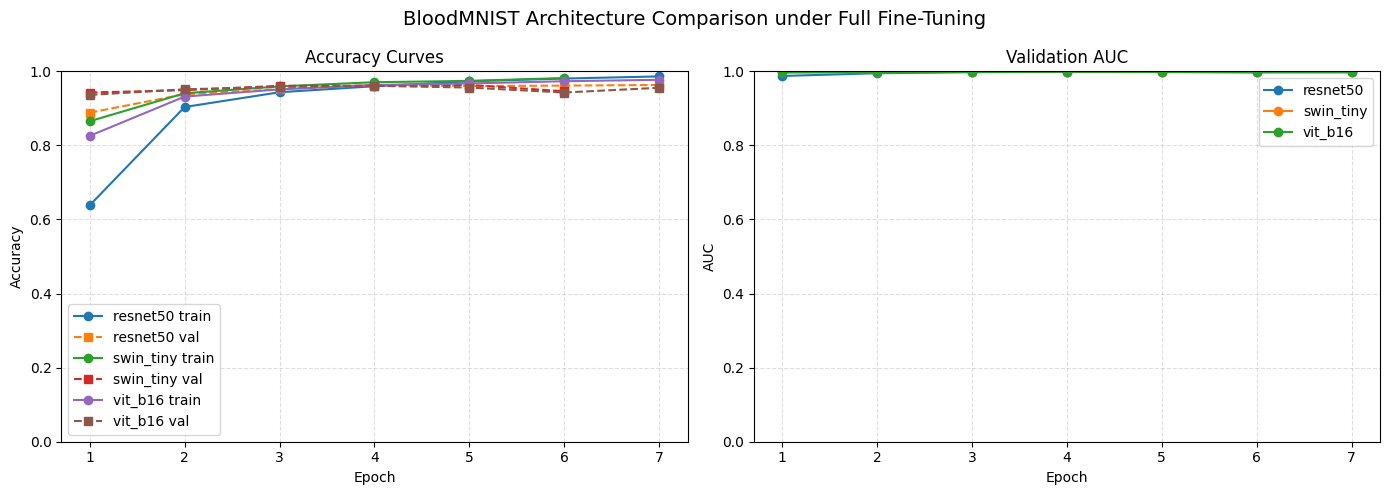

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for result in results:
    epochs = range(1, len(result["history"]["train_loss"]) + 1)
    axes[0].plot(epochs, result["history"]["train_acc"], marker="o", label=f"{result['model_key']} train")
    axes[0].plot(epochs, result["history"]["val_acc"], marker="s", linestyle="--", label=f"{result['model_key']} val")
    axes[1].plot(epochs, result["history"]["val_auc"], marker="o", label=result["model_key"])

axes[0].set_title("Accuracy Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.0)
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

axes[1].set_title("Validation AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend()

fig.suptitle("BloodMNIST Architecture Comparison under Full Fine-Tuning", fontsize=14)
fig.tight_layout()

plot_path = figures_dir / "bloodmnist_architecture_comparison_training_curves.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {plot_path}")
plt.show()


Saved plot to: figures\bloodmnist_architecture_comparison_test_metrics.png


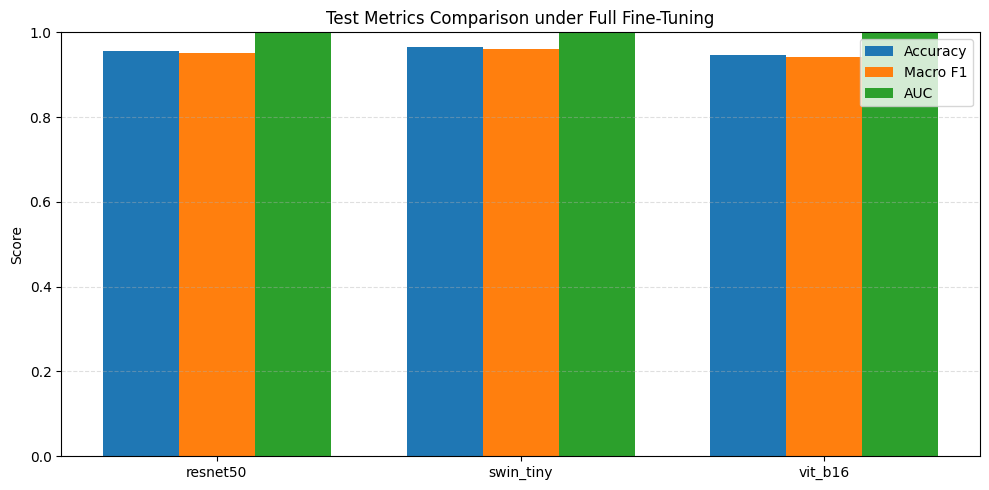

In [9]:
labels = [result["model_key"] for result in results]
test_acc = [result["test_metrics"]["accuracy"] for result in results]
test_f1 = [result["test_metrics"]["macro_f1"] for result in results]
test_auc = [result["test_metrics"]["auc"] for result in results]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, test_acc, width=width, label="Accuracy")
ax.bar(x, test_f1, width=width, label="Macro F1")
ax.bar(x + width, test_auc, width=width, label="AUC")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Test Metrics Comparison under Full Fine-Tuning")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend()

bar_plot_path = figures_dir / "bloodmnist_architecture_comparison_test_metrics.png"
fig.tight_layout()
fig.savefig(bar_plot_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {bar_plot_path}")
plt.show()
